# Accounting Conservatism (C-Score) — a quantitative teardown 🔬
### A point-in-time calendar-time tercile long-short (Newey-West) · a pooled event-drift cross-check with a label-shuffle placebo · an era split · a NOA-scaled variant · the Basu asymmetric-timeliness regression · a 12-seed synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Conservative%3F: Suggestive](https://img.shields.io/badge/Conservative%3F-Suggestive-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — a **Penman-Zhang / Basu conservatism score leads returns** — splits into two testable pieces: *is the accounting conservative* (Basu) and *does the score sort returns* (the long-short). The first is faintly true; the second is a clean null. This is distinct from every sibling on the desk: [229](../../229-beneish-m-score/) detects income-*inflating* manipulation, [232](../../232-mohanram-g-score/) is a growth composite, [855](../../855-accrual-quality/) measures accrual-to-cash mapping.

> ⚠️ **Data note.** EDGAR reserve/allowance tags (`AllowanceForDoubtfulAccountsReceivableCurrent` + `InventoryValuationReserves` + `DeferredTaxAssetsValuationAllowance`) ÷ Assets + yfinance adjusted closes, 37 names, ends 2008-09-27 → 2026-05-31, as-of 2026-06-30. Point-in-time on the **filing date**. Survivorship named on the Signal axis (current-survivors basket). A **coarse reserve floor** on thin/uneven coverage is a first-class caveat. Numbers in [`docs/results.md`](../docs/results.md) (prices fingerprint `5506b659db08`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from conservatism import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX, EV = data.load_real()
else:
    PX = EV = None
print("real cache present:", HAVE_REAL, "| events:", (0 if EV is None else len(EV)),
      "| names:", (0 if EV is None else EV['ticker'].nunique()))

# frozen headline numbers (mirror of docs/results.md)
R = {'as_of': '2026-06-30', 'n_names': 37, 'n_events': 1669, 'end_lo': '2008-09-27', 'end_hi': '2026-05-31', 'fp_prices': '5506b659db08', 'cscore_med': 0.34, 'cscore_mean': 0.98, 'n_months': 202, 'avg_n': 28.5, 'ls_span_lo': '2009-09-30', 'ls_span_hi': '2026-06-30', 'ls_mean_bps': 4.0, 'ls_ann': 0.49, 'ls_t_iid': 0.21, 'ls_t_nw': 0.22, 'ls_sharpe': 0.05, 'ls_hit': 49, 'ls_long_bps': 152.4, 'ls_short_bps': 148.4, 'ls_turn': 0.21, 'ls_cum': 1.005, 'ls120_mean_bps': -9.4, 'ls120_t_nw': -0.43, 'noa_n': 194, 'noa_mean_bps': 0.6, 'noa_t_nw': 0.02, 'xsec_early': 20, 'xsec_late': 31, 'noa_cov': 42, 'drift': {21: (1667, 1.4, 1.47, -0.07, -0.17, 49, 0.565), 63: (1646, 3.57, 4.26, -0.68, -0.91, 49, 0.8345), 126: (1615, 6.55, 7.91, -1.36, -1.31, 48, 0.9211)}, 'mono63': (4.26, 2.57, 3.57), 'mono126': (7.91, 5.62, 6.55), 'era_early_n': 76, 'era_early_bps': 17.8, 'era_early_t': 0.55, 'era_late_n': 126, 'era_late_bps': -4.3, 'era_late_t': -0.2, 'basu_n': 1607, 'basu_b_good': 0.006, 'basu_b_asym': 0.025, 'basu_t': 1.67, 'basu_r2': 0.005, 'net': {(10, 50): (-4.3, -0.51, -0.24, -0.05), (20, 100): (-12.5, -1.51, -0.7, -0.16)}, 'syn_null_mean': 0.47, 'syn_null_sd': 0.76, 'syn_null_fire': 0, 'syn_null_seeds': 12, 'syn_planted_bps': 1057.5, 'syn_planted_t': 26.57}


real cache present: True | events: 1669 | names: 37


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** (returns) | `NONE` | calendar tercile long-short **+4.0 bps/mo** (+0.5%/yr gross), one-sample *t* = +0.21, **Newey-West *t* = +0.22**; staleness-120 flips to -9.4 bps (NW *t* = -0.43), NOA-scaled NW *t* = +0.02; pooled drift negative, sign flips by era |
| **Tradability** | `MIRAGE` | net of 20 bps + 100 bps borrow: -1.51%/yr, NW *t* = -0.70, Sharpe -0.16; no gross edge to begin with |
| **Is the accounting conservative?** | `SUGGESTIVE` | Basu asymmetry $b_3$ = +0.025 (*t* = +1.67, R² = 0.005) — faintly positive |

> 💡 In plain words: the panel is *mildly* conservative and the return edge is a flat (if anything wrong-signed) null. A coarse public reserve ratio proxies a faint accounting property that the market has already priced.

## 1 · The claim, steelmanned

Let $\text{Res}_{i,q}$ be name $i$'s tagged estimated reserves at fiscal quarter $q$, disclosed on filing date $F_{i,q}$. The C-score is the point-in-time reserve intensity $c_{i,q} = \text{Res}_{i,q}/\text{Assets}_{i,q}$, known at $F_{i,q}$. The claims:

- **H₁ (conservative accounting).** The panel books bad news faster than good — a positive Basu interaction $b_3$ in $\text{ROA} = a + b_1 R + b_2 D + b_3 (D\cdot R)$, $D = \mathbb{1}[R<0]$.
- **H₂ (leads returns).** A cross-sectional long-short on $c$ (long high / short low) earns a positive forward return spread — the market-mispricing claim.
- **H₃ (tradable).** That spread survives realistic long-short costs + borrow.

We find **H₁ weakly supported** ($b_3$ = +0.025, *t* = +1.67), **H₂ not supported** (NW *t* = +0.22, negative and non-monotone event drift), and therefore **H₃ moot** (nothing to trade). The literature (Basu 1997; Penman-Zhang 2002) supports a real conservatism property; our coarse tape captures it faintly and finds **no** associated return premium — hence a `NONE` on returns, not a `WEAK`: the point estimate is essentially zero and not even robustly right-signed.

## 2 · So what? — inference design

The primary is a **calendar-time** long-short, not a pooled event study, precisely because balance-sheet signals are persistent and filings cluster: a calendar series of monthly long-short returns lets a **Newey-West (6-lag) HAC *t*** do the honest work the desk's `REAL` bar is written against. The panel is thin, so we sort into **terciles** (not quintiles) and require ≥ 6 names in the cross-section. The pooled event drift + a **label-shuffle placebo** is the cross-check; the Basu regression is graded on **sign and magnitude** (its pooled *t* ignores quarter clustering).

## 3 · How we'd know — the protocol

- **Panel.** 1,669 (ticker, filing) reserve-disclosing quarters across 37 names, ends 2008-09-27 → 2026-05-31, each stamped with its 10-Q/10-K filing date (point-in-time).
- **Primary.** Monthly tercile long-short on `cscore`, one execution lag (rank at month $M$ close, earn month $M{+}1$); Newey-West + one-sample *t*, Sharpe, hit rate.
- **Cross-check.** Pooled event drift over 21/63/126 trading days, one-day-lag entry, top-minus-bottom tercile, one-sample *t* + 10k-draw label-shuffle placebo, and the tercile monotonicity picture.
- **Robustness.** Staleness 120 vs 200 days; the NOA-scaled signal `reserves/NOA`; an era split at 2016.
- **Mechanism.** Pooled Basu (1997) asymmetric-timeliness regression.
- **Execution.** Long-short net of one-way cost × turnover (both legs) + short borrow.
- **Control.** Synthetic panel, planted-relation knob; the null must not fire across 12 seeds.

## 4 · The teardown

### 4a · The primary — calendar-time tercile long-short (Newey-West)

Rank fresh scores into terciles each month, long the most conservative / short the least equal-weight, earn next month's return. The decisive statistic is the HAC *t* of the monthly long-short series.

calendar long-short: +4.0 bps/mo (+0.49%/yr gross), n=202 months, avg cross-section 28.5
  one-sample t = +0.21   Newey-West(6) t = +0.22   Sharpe 0.05   hit 49%   turnover 0.21
  NOA-scaled signal: +0.6 bps/mo, NW t = +0.02, n=194


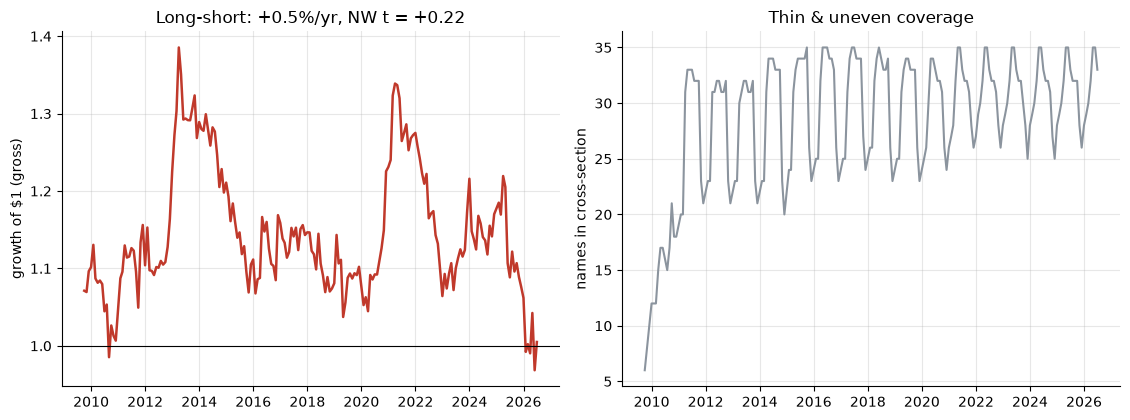

frozen: +4.0 bps/mo, NW t = +0.22, staleness-120 NW t = -0.43, NOA-scaled NW t = +0.02


In [2]:
if HAVE_REAL:
    ls = st.calendar_ls(PX, EV, signal_col='cscore', n_buckets=3, min_names=6, staleness_days=200)
    s = st.calendar_ls_stats(ls)
    ls_noa = st.calendar_ls(PX, EV, signal_col='cscore_noa', n_buckets=3, min_names=6, staleness_days=200)
    s_noa = st.calendar_ls_stats(ls_noa)
    print(f"calendar long-short: {s['mean_bps']:+.1f} bps/mo (+{s['ann_pct']:.2f}%/yr gross), "
          f"n={s['n_months']} months, avg cross-section {s['avg_n']:.1f}")
    print(f"  one-sample t = {s['t_iid']:+.2f}   Newey-West(6) t = {s['t_nw']:+.2f}   "
          f"Sharpe {s['sharpe']:.2f}   hit {s['hit']*100:.0f}%   turnover {s['avg_turnover']:.2f}")
    print(f"  NOA-scaled signal: {s_noa['mean_bps']:+.1f} bps/mo, NW t = {s_noa['t_nw']:+.2f}, n={s_noa['n_months']}")
    cum = (1+ls['ls']).cumprod(); nser = ls['n']
else:
    cum = None; nser = None
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.4, 4.3))
if cum is not None:
    a1.plot(cum.index, cum.values, color=RED, lw=1.8); a1.axhline(1, c='k', lw=.8)
    a1.set_ylabel('growth of $1 (gross)'); a1.set_title(f"Long-short: +{R['ls_ann']:.1f}%/yr, NW t = {R['ls_t_nw']:+.2f}")
    a2.plot(nser.index, nser.values, color=GREY, lw=1.5); a2.set_ylabel('names in cross-section')
    a2.set_title('Thin & uneven coverage')
else:
    for a in (a1,a2): a.text(.5,.5,'run with cache',ha='center'); a.set_axis_off()
plt.tight_layout(); plt.show()
print(f"frozen: {R['ls_mean_bps']:+.1f} bps/mo, NW t = {R['ls_t_nw']:+.2f}, "
      f"staleness-120 NW t = {R['ls120_t_nw']:+.2f}, NOA-scaled NW t = {R['noa_t_nw']:+.2f}")

> 💡 In plain words: **+4 bps/month** is a rounding error (~+0.5%/yr gross), and the HAC *t* is **+0.22** — a flat null over n=202 months. Every specification agrees and none is even reliably positive: staleness-120 NW *t* = -0.43 (negative), the cleaner NOA-scaled signal NW *t* = +0.02 (dead zero). There is no conservatism return premium to certify — right-signed or otherwise.

### 4b · The cross-check — pooled event drift + placebo + monotonicity

Bucket all events by the score; top-minus-bottom forward drift with a label-shuffle null. If there were a sort, the terciles would form a ladder.

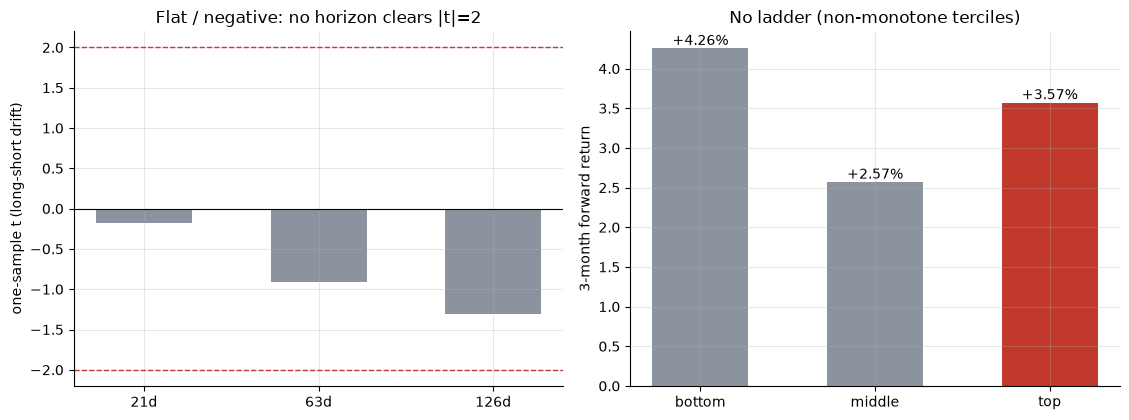

  H= 21d: long-short -0.07%  t=-0.17  win=49%  placebo p=0.554
  H= 63d: long-short -0.68%  t=-0.91  win=49%  placebo p=0.833
  H=126d: long-short -1.36%  t=-1.31  win=48%  placebo p=0.919


In [3]:
rows = []
if HAVE_REAL:
    for h in st.HORIZONS:
        es = st.event_summary(PX, EV, horizon=h, n_buckets=3, n_draws=4000)
        rows.append((h, es['ls_mean']*100, es['t'], es['ls_win']*100, es['p_placebo']))
    mono = st.bucket_means(st.event_drift_frame(PX, EV, horizon=63), 3)*100
else:
    for h in st.HORIZONS:
        d = R['drift'][h]; rows.append((h, d[3], d[4], d[5], d[6]))
    mono = np.array(R['mono63'])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.4, 4.3))
hs = [r[0] for r in rows]; ts = [r[2] for r in rows]
a1.bar([f'{h}d' for h in hs], ts, color=GREY, width=.55)
a1.axhline(2, ls='--', c=RED, lw=1); a1.axhline(-2, ls='--', c=RED, lw=1); a1.axhline(0, c='k', lw=.8)
a1.set_ylabel('one-sample t (long-short drift)'); a1.set_title('Flat / negative: no horizon clears |t|=2')
a2.bar(['bottom','middle','top'], mono, color=[GREY, GREY, RED], width=.55)
for i,v in enumerate(mono): a2.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom')
a2.set_ylabel('3-month forward return'); a2.set_title('No ladder (non-monotone terciles)')
plt.tight_layout(); plt.show()
for h,ls_,t,win,p in rows:
    print(f'  H={h:>3}d: long-short {ls_:+.2f}%  t={t:+.2f}  win={win:.0f}%  placebo p={p:.3f}')

> 💡 In plain words: the pooled long-short drift is **negative** at every horizon (*t* from -0.17 to -1.31), the label-shuffle placebo *p* climbs to **0.92** (a random tercile split beats the real one ~9 times in 10, because the real one is mildly wrong-signed), and the terciles are **non-monotone** (+4.26% / +2.57% / +3.57% low→high at 63d). The event study and the calendar long-short agree: no return sort in the claimed direction.

### 4c · Era split — nothing hiding in a regime

Split the calendar long-short at 2016.

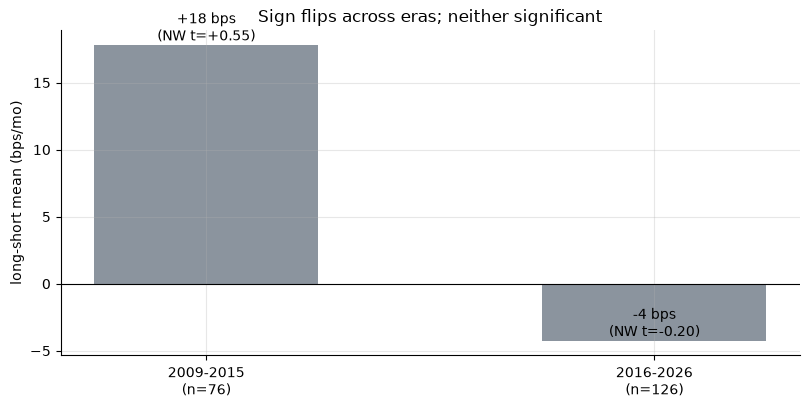

2009-2015: +17.8 bps NW t=+0.55 (n=76)  |  2016-2026: -4.3 bps NW t=-0.20 (n=126)


In [4]:
if HAVE_REAL:
    e = ls[ls.index < '2016-01-01']['ls'].to_numpy(); l = ls[ls.index >= '2016-01-01']['ls'].to_numpy()
    eb, et, en = e.mean()*1e4, st.newey_west_t(e), len(e)
    lb, lt, ln = l.mean()*1e4, st.newey_west_t(l), len(l)
else:
    eb, et, en = R['era_early_bps'], R['era_early_t'], R['era_early_n']
    lb, lt, ln = R['era_late_bps'], R['era_late_t'], R['era_late_n']
fig, ax = plt.subplots(figsize=(8.2, 4.2))
ax.bar([f'2009-2015\n(n={en})', f'2016-2026\n(n={ln})'], [eb, lb], color=[GREY, GREY], width=.5)
for i,(v,t_) in enumerate([(eb,et),(lb,lt)]): ax.annotate(f'{v:+.0f} bps\n(NW t={t_:+.2f})',(i,v),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('long-short mean (bps/mo)')
ax.set_title('Sign flips across eras; neither significant')
plt.tight_layout(); plt.show()
print(f'2009-2015: {eb:+.1f} bps NW t={et:+.2f} (n={en})  |  2016-2026: {lb:+.1f} bps NW t={lt:+.2f} (n={ln})')

> 💡 In plain words: +18 bps (NW *t* = +0.55) early, -4 bps (NW *t* = -0.20) late — the **sign flips** and neither half certifies. Not a live edge that decayed; it never existed.

### 4d · The mechanism — is the panel actually conservative? (Basu 1997)

Pooled regression of quarterly ROA on the contemporaneous return, a bad-news dummy, and their interaction. The interaction slope $b_3$ is Basu's asymmetric timeliness.

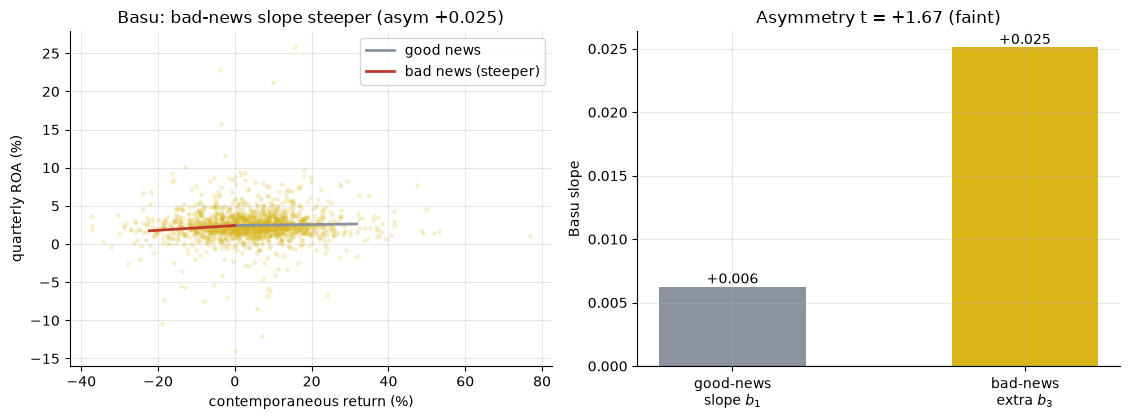

Basu: good-news b1 +0.006, bad-news extra b3 +0.025, t(b3) +1.67


In [5]:
if HAVE_REAL:
    q = st.basu_asymmetry(EV)
    fr = EV.dropna(subset=['roa','ret_contemp'])
    r, y = fr['ret_contemp'].to_numpy(), fr['roa'].to_numpy()
    m = (np.abs(r)<1.5)&(np.abs(y)<0.5)
    r, y = r[m], y[m]
    b_good, b_asym, t_asym = q['b_good'], q['b_asym'], q['t_asym']
else:
    r = y = None
    b_good, b_asym, t_asym = R['basu_b_good'], R['basu_b_asym'], R['basu_t']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.4, 4.3))
if r is not None:
    a1.scatter(r*100, y*100, s=6, alpha=.15, color=AMBER)
    xs_neg = np.linspace(np.percentile(r,2), 0, 25); xs_pos = np.linspace(0, np.percentile(r,98), 25)
    a = y.mean() - (b_good)*r.mean()
    a1.plot(xs_pos*100, (a + b_good*xs_pos)*100, color=GREY, lw=2, label='good news')
    a1.plot(xs_neg*100, (a + (b_good+b_asym)*xs_neg)*100, color=RED, lw=2, label='bad news (steeper)')
    a1.set_xlabel('contemporaneous return (%)'); a1.set_ylabel('quarterly ROA (%)'); a1.legend()
    a1.set_title(f'Basu: bad-news slope steeper (asym {b_asym:+.3f})')
else:
    a1.text(.5,.5,'run with cache',ha='center'); a1.set_axis_off()
a2.bar(['good-news\nslope $b_1$','bad-news\nextra $b_3$'], [b_good, b_asym], color=[GREY, AMBER], width=.5)
for i,v in enumerate([b_good, b_asym]): a2.annotate(f'{v:+.3f}',(i,v),ha='center',va='bottom')
a2.axhline(0, c='k', lw=.8); a2.set_ylabel('Basu slope'); a2.set_title(f'Asymmetry t = {t_asym:+.2f} (faint)')
plt.tight_layout(); plt.show()
print(f'Basu: good-news b1 {b_good:+.3f}, bad-news extra b3 {b_asym:+.3f}, t(b3) {t_asym:+.2f}')

> 💡 In plain words: the interaction is **positive** ($b_3$ = +0.025) — earnings do bite a little harder on bad news — so the panel is **genuinely, faintly conservative** (*t* = +1.67, R² = 0.005). The accounting property the C-score means to proxy is real but weak on this coarse quarterly measure. The return null is therefore **not** a machinery failure — it's a market-efficiency result: a faint, public accounting property carries no forward-return edge. (The Basu *t* is pooled across clustered filings; we read sign + magnitude, not the literal value.)

### 4e · Tradability — the timer

For completeness, the calendar long-short net of one-way costs × turnover (both legs) + short borrow — though a near-zero gross *t* already settles it.

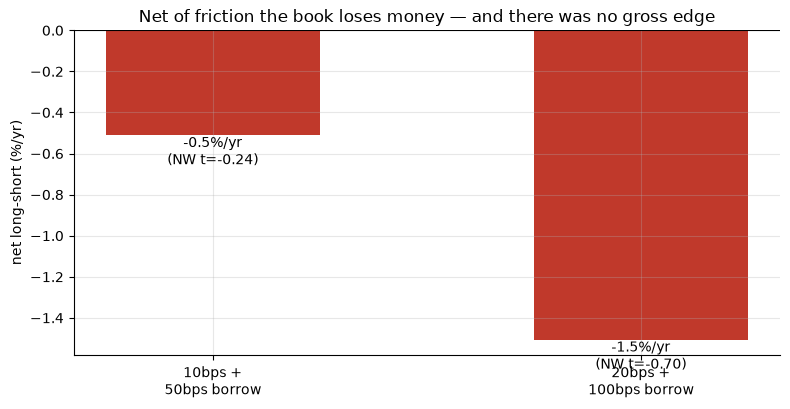

  cost 10bps + borrow 50bps/yr: -0.51%/yr net, NW t=-0.24, Sharpe -0.05
  cost 20bps + borrow 100bps/yr: -1.51%/yr net, NW t=-0.70, Sharpe -0.16


In [6]:
rows = []
if HAVE_REAL:
    for cb, bb in [(10.0,50.0),(20.0,100.0)]:
        nt = st.calendar_ls_net(ls, cost_bps=cb, borrow_bps_ann=bb)
        rows.append((cb, bb, nt['net_ann_pct'], nt['net_t_nw'], nt['net_sharpe']))
else:
    for (cb,bb),v in R['net'].items(): rows.append((cb, bb, v[1], v[2], v[3]))
labels = [f'{int(cb)}bps +\n{int(bb)}bps borrow' for cb,bb,_,_,_ in rows]
anns = [r[2] for r in rows]
fig, ax = plt.subplots(figsize=(8.0, 4.2))
ax.bar(labels, anns, color=[RED, RED], width=.5)
for i,(cb,bb,a,t,sh) in enumerate(rows): ax.annotate(f'{a:+.1f}%/yr\n(NW t={t:+.2f})',(i,a),ha='center',va='top')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('net long-short (%/yr)')
ax.set_title('Net of friction the book loses money — and there was no gross edge')
plt.tight_layout(); plt.show()
for cb,bb,a,t,sh in rows: print(f'  cost {int(cb)}bps + borrow {int(bb)}bps/yr: {a:+.2f}%/yr net, NW t={t:+.2f}, Sharpe {sh:.2f}')

> 💡 In plain words: turnover is modest (~0.21/mo) but irrelevant — the gross edge was already zero, so net of 20 bps + 100 bps borrow the book runs **-1.5%/yr** (NW *t* = -0.70, Sharpe -0.16). **Tradability = MIRAGE.**

### 4f · Faithful-engine & power control

Synthetic price + score panel with a TUNABLE planted relation (high-conservatism names drift up). The null (edge = 0) is checked over **12 seeds**.

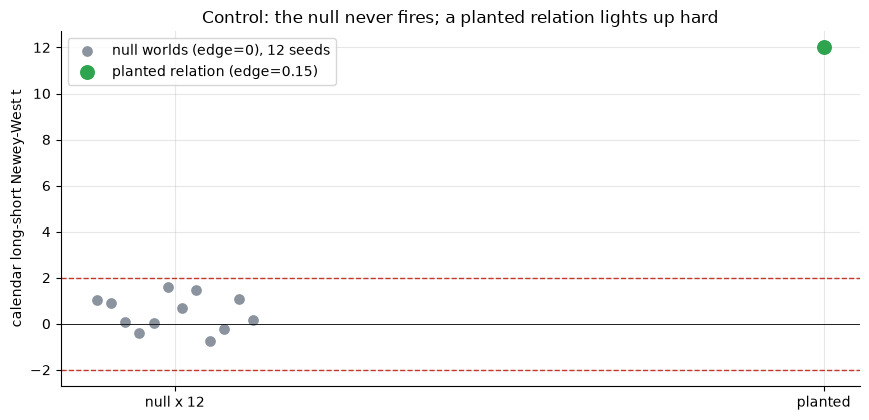

null: mean NW t = +0.47 (sd 0.76), |t|>=2 in 0/12  |  planted NW t = +26.57


In [7]:
null_ts = []
for s_ in range(12):
    p0, e0 = data.synthetic_panel(edge=0.0, seed=860 + s_)
    null_ts.append(st.synthetic_detect(p0, e0)['t_nw'])
null_ts = np.asarray(null_ts)
p1, e1 = data.synthetic_panel(edge=0.15, seed=860)
planted_t = st.synthetic_detect(p1, e1)['t_nw']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.linspace(-.12,.12,12), null_ts, color=GREY, s=45, label='null worlds (edge=0), 12 seeds')
ax.scatter([1], [min(planted_t, 12)], color=GREEN, s=95, zorder=5, label='planted relation (edge=0.15)')
ax.axhline(2, ls='--', c=RED, lw=1); ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(0, c='k', lw=.6)
ax.set_xticks([0,1]); ax.set_xticklabels(['null x 12','planted'])
ax.set_ylabel('calendar long-short Newey-West t')
ax.set_title('Control: the null never fires; a planted relation lights up hard'); ax.legend()
plt.tight_layout(); plt.show()
print(f'null: mean NW t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/12  |  planted NW t = {planted_t:+.2f}')

> 💡 In plain words: across 12 null worlds the detector averages NW *t* = +0.47 (sd 0.76) and crosses |t|=2 0/12 times; a planted relation reads NW *t* = 26.6. The machinery is unbiased and powered, so the real-tape +0.22 is a genuine null, not a broken pipeline. *(Power check only — never cited in support of a real-tape stamp.)*

## 5 · The verdict

- **Signal (returns) `NONE`** — calendar tercile long-short +4.0 bps/mo (+0.5%/yr gross), one-sample *t* = +0.21, **Newey-West *t* = +0.22**; staleness-120 -9.4 bps (NW *t* = -0.43), NOA-scaled NW *t* = +0.02; pooled event drift **negative** and non-monotone (placebo *p* up to 0.92); the sign flips across eras. A flat, not-even-right-signed null.
- **Tradability `MIRAGE`** — net of 20 bps + 100 bps borrow: -1.51%/yr, NW *t* = -0.70, Sharpe -0.16; no gross edge to monetise.
- **Is the accounting conservative? `SUGGESTIVE`** — Basu asymmetry $b_3$ = +0.025, *t* = +1.67, R² = 0.005. A faint, real bad-news asymmetry; the property exists but is weak, coarsely proxied, and already priced.

## 6 · Going further

- **The residual worth chasing** is the *change* in conservatism, not the *level*: reserve *releases* that flatter earnings (the Penman-Zhang temporal story), or a sharper C-score built from the reserves XBRL doesn't expose (LIFO, capitalised R&D, advertising). A faint public level that the market already prices is the textbook signature of an efficiently-priced fundamental.
- **Coverage honesty:** reserve tags are irregular — most names disclose only the bad-debt allowance, and only some years — so our score is a *floor* on true reserves and the cross-section is thin (≈20 names early → ≈31 late; only 42% carry the NOA denominator). The flat/negative event drift across 1,600+ pooled events is the more decisive evidence of the return null.
- **Dedup map:** [229-beneish-m-score](../../229-beneish-m-score/) (detects the *opposite* — income-inflating manipulation), [232-mohanram-g-score](../../232-mohanram-g-score/) (a growth-firm fundamental composite), [855-accrual-quality](../../855-accrual-quality/) (how well accruals map to cash), [52-smoke-screen](../../52-smoke-screen/) (a method demo of spurious accounting overlays). None ranks on reserve-intensity conservatism itself.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*